You might recall that an eigenstate of one operator, Z, is not an eigenstate of another operator X. We will observe that now, experimentally by making measurements along the x and z axes. For the measurement along z, we simply use qc.measure(), because IBM quantum computers are structured to measure along z. But to measure along x, we must rotate the system to effectively move the x axis up to the orientation along which we measure. This is accomplished with a Hadamard gate. There is a similar step required for measurements along y. The necessary steps are collected here for convenience:

To measure along z: qc.measure()
To measure along x: qc.h() then qc.measure()
To measure along y: qc.sdg(), qc.h(), qc.sthen qc.measure()

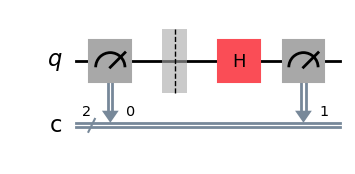

In [15]:
# Step 1: Map

# Import some general packages
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(2, "c")
qc = QuantumCircuit(qr, cr)

# Add a first measurement
qc.measure(qr, cr[0])
qc.barrier()

# Change basis so that measurements made on quantum computer which normally tell us about z, now tell us about x.
qc.h(qr)

# Add a second measurement
qc.measure(qr, cr[1])

qc.draw("mpl")

In [18]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend_sim.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc)

In [21]:
from qiskit_aer import AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2 as GB
from qiskit.primitives import BackendSamplerV2 as BS, BackendEstimatorV2 as BE
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

fake_hardware = GB(num_qubits=7)
backend_sim = AerSimulator.from_backend(fake_hardware)
sampler_sim = BS(backend=backend_sim)
estimator_sim = BE(backend=backend_sim)

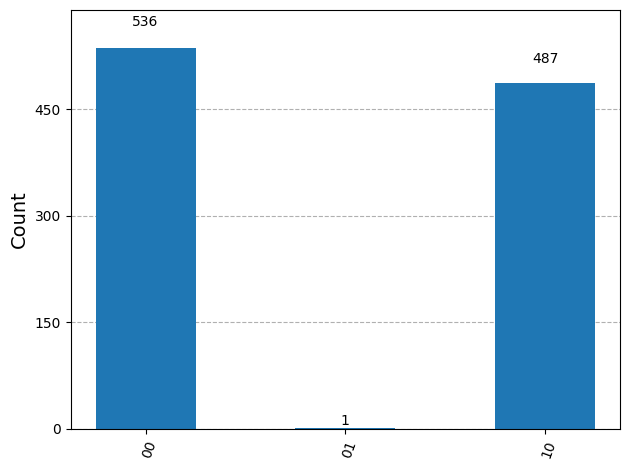

In [22]:
# Step 3: Run the job on a real quantum computer


# sampler = Sampler(mode=backend)
# pubs = [qc_isa]
# job = sampler.run(pubs)
# res = job.result()

# counts = res[0].data.c.get_counts()

# Run the job on the Aer simulator with noise model from real backend

job = sampler_sim.run([qc_isa])
res=job.result()
counts=res[0].data.c.get_counts()

# Step 4: Post-process

from qiskit.visualization import plot_histogram

plot_histogram(counts)

If this convention does not appeal to you, you can use marginal_counts to visualize the results of each measurement separately:

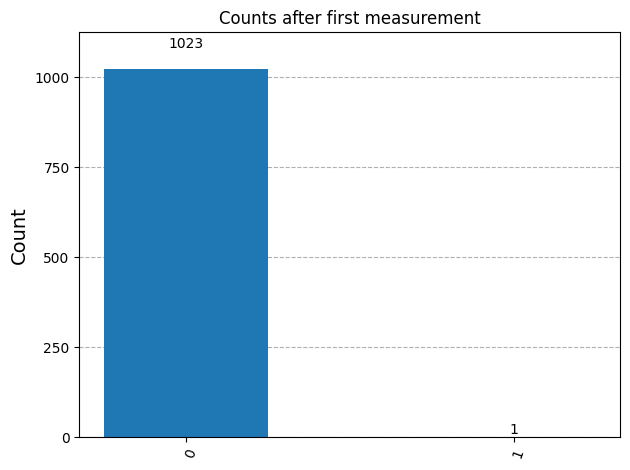

In [23]:
from qiskit.result import marginal_counts

plot_histogram(
    marginal_counts(counts, indices=[0]), title="Counts after first measurement"
)

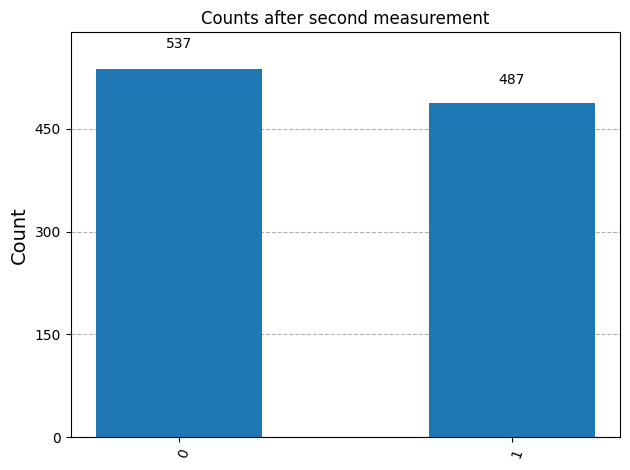

In [24]:
plot_histogram(
    marginal_counts(counts, indices=[1]), title="Counts after second measurement"
)

What happens if the make the measurements in the opposite order? We could start by using the Hadamard gate to obtain statistics on the probability of ∣0⟩ being measured in ∣±⟩x. Then for the second measurement, we will change back to the z basis using a second Hadamard gate.

Same code as above, just clubbed and added hadamard in th beginning

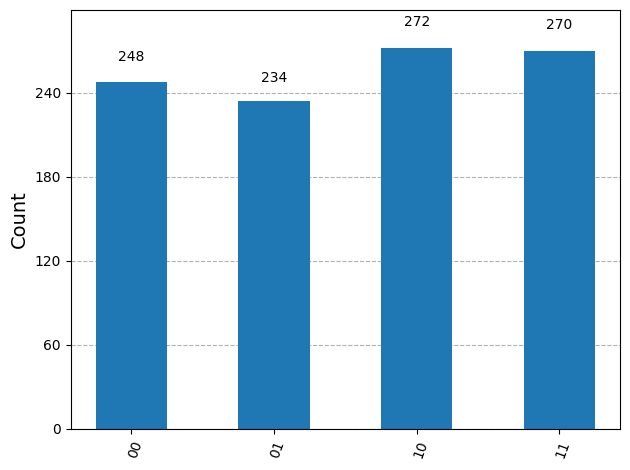

In [26]:
from qiskit_aer import AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2 as GB
from qiskit.primitives import BackendSamplerV2 as BS, BackendEstimatorV2 as BE
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

qr = QuantumRegister(1, "q")
cr = ClassicalRegister(2, "c")
qc = QuantumCircuit(qr, cr)

# Change basis to measure along x.
qc.h(qr)
qc.measure(qr, cr[0])
qc.barrier()
# Change our basis back to z and make a second measurement
qc.h(qr)

# qc.measure(qr, cr[0])
# qc.barrier()
# qc.h(qr)

qc.measure(qr, cr[1])

qc.draw("mpl")

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend_sim.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc)



fake_hardware = GB(num_qubits=7)
backend_sim = AerSimulator.from_backend(fake_hardware)
sampler_sim = BS(backend=backend_sim)
estimator_sim = BE(backend=backend_sim)
job = sampler_sim.run([qc_isa])
res=job.result()
counts=res[0].data.c.get_counts()


from qiskit.visualization import plot_histogram

plot_histogram(counts)

We can create an arbitrary initial state using qc.initialize(). Note that the syntax for the imaginary unit here is 1j.

In [30]:
# Step 1: Map the problem into a quantum circuit

from qiskit.quantum_info import SparsePauliOp
import numpy as np

obs = SparsePauliOp("X")

# Define registers
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

# Initialize the state
qc.initialize([1, 1j] / np.sqrt(2))

# Step 2: Transpile the circuit

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

# Step 3: Run the circuit on a real quantum computer


# estimator = Estimator(mode=backend)
# pubs = [(qc_isa, obs_isa)]
# job = estimator.run([[qc_isa, obs_isa]])
# res = job.result()

# Run the job on the Aer simulator with noise model from real backend
job = estimator_sim.run([[qc_isa,obs_isa]])
res=job.result()

# Step 4: Return the result in classical form, and analyze.

print(res[0].data.evs)

-0.00634765625


According to our equation above,
(ΔX)2
 =1−⟨X⟩2
 =1−(0.0015...)2
 →ΔX=0.999... Let's stick with that same state, but find the expectation value of Z, now:

In [31]:
obs = SparsePauliOp("X")

qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

qc.initialize([1, 1j] / np.sqrt(2))

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)
job = estimator_sim.run([[qc_isa,obs_isa]])
res=job.result()
print(res[0].data.evs)

0.0048828125


Recall that there is an uncertainty relation between position along one direction, 
Let's see what happens. Note that in the code below, estimator can accept two sets of circuits and observables in the same job submission.

In [32]:
obs1 = SparsePauliOp("X")
obs2 = SparsePauliOp("Z")

qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

qc.initialize([1, 1j] / np.sqrt(2))

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs1_isa = obs1.apply_layout(layout=qc_isa.layout)
obs2_isa = obs2.apply_layout(layout=qc_isa.layout)
job = estimator_sim.run([[qc,obs1],[qc,obs2]])
res=job.result()
print("The expectation value of the first observable is: ", res[0].data.evs)
print("The expectation value of the second observable is: ", res[1].data.evs)

The expectation value of the first observable is:  -0.00439453125
The expectation value of the second observable is:  -0.03564453125


The test above only demonstrated the validity of the uncertainty relation for a single choice of state vector
∣ψ⟩=∣+⟩ x. To convince ourselves that this is generally consistent with experiment, we should carry out similar calculations using estimator for many choices of the state vector. Let's start by rotating our state vector away from the z axis, using an RY gate to produce different initial states using a parameter θ.

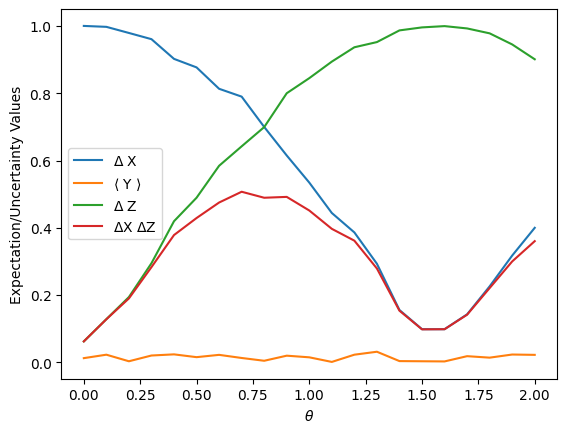

In [ ]:
from qiskit.circuit import Parameter
import numpy as np

obs1 = SparsePauliOp("X")
obs2 = SparsePauliOp("Y")
obs3 = SparsePauliOp("Z")

qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

theta = Parameter("θ")
qc.ry(theta, 0)

params = np.linspace(0, 2, num=21)

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

obs1_isa = obs1.apply_layout(layout=qc_isa.layout)
obs2_isa = obs2.apply_layout(layout=qc_isa.layout)
obs3_isa = obs3.apply_layout(layout=qc_isa.layout)

param_values = np.array(params).reshape(-1, 1)

job = estimator_sim.run([
    (qc_isa, obs1_isa, param_values),
    (qc_isa, obs2_isa, param_values),
    (qc_isa, obs3_isa, param_values)
])
#job = estimator_sim.run([[qc,obs1],[qc,obs2],[qc,obs3]])
res=job.result()

# Step 4: Post-processing and classical analysis.
xs = res[0].data.evs
ys = abs(res[1].data.evs)
zs = res[2].data.evs

# Calculate uncertainties

delx = []
delz = []
prodxz = []
for i in range(len(xs)):
    delx.append(abs((1 - xs[i] * xs[i])) ** 0.5)
    delz.append(abs((1 - zs[i] * zs[i])) ** 0.5)
    prodxz.append(delx[i] * delz[i])


# Here we can plot the results from this simulation.
import matplotlib.pyplot as plt

plt.plot(params, delx, label=r"$\Delta$ X")
plt.plot(params, ys, label=r"$\langle$ Y $\rangle$")
plt.plot(params, delz, label=r"$\Delta$ Z")
plt.plot(params, prodxz, label=r"$\Delta$X $\Delta$Z")
plt.xlabel(r"$\theta$")
plt.ylabel("Expectation/Uncertainty Values")
plt.legend()
plt.show()

Of course, this might not be the best test of the uncertainty relation, since our limit ⟨Y⟩ is always very close to zero. Let's use a quantum state that has a larger projection on eigenstates of Y. Specifically, we will still rotate rotate ∣0⟩ down from the z axis by varying angles, but now we will also rotate that resulting state around z by some angle, perhaps π/4, and see what happens.

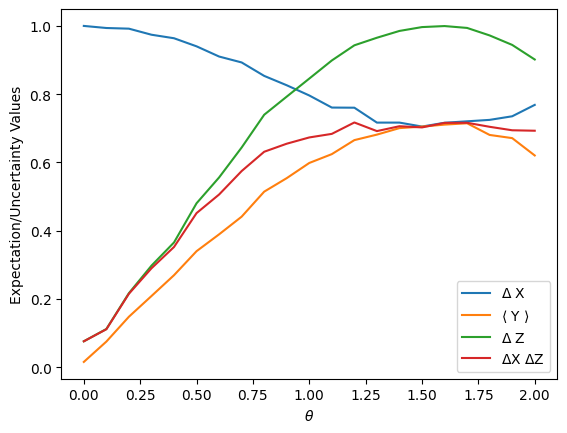

In [42]:
from qiskit.circuit import Parameter
import numpy as np

obs1 = SparsePauliOp("X")
obs2 = SparsePauliOp("Y")
obs3 = SparsePauliOp("Z")

qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
qc = QuantumCircuit(qr, cr)

theta = Parameter("θ")
qc.ry(theta, 0)
qc.rz(np.pi /4, 0)

params = np.linspace(0, 2, num=21)

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

obs1_isa = obs1.apply_layout(layout=qc_isa.layout)
obs2_isa = obs2.apply_layout(layout=qc_isa.layout)
obs3_isa = obs3.apply_layout(layout=qc_isa.layout)

param_values = np.array(params).reshape(-1, 1)

job = estimator_sim.run([
    (qc_isa, obs1_isa, param_values),
    (qc_isa, obs2_isa, param_values),
    (qc_isa, obs3_isa, param_values)
])
res=job.result()

xs = res[0].data.evs
ys = abs(res[1].data.evs)
zs = res[2].data.evs

delx = []
delz = []
prodxz = []
for i in range(len(xs)):
    delx.append(abs((1 - xs[i] * xs[i])) ** 0.5)
    delz.append(abs((1 - zs[i] * zs[i])) ** 0.5)
    prodxz.append(delx[i] * delz[i])


import matplotlib.pyplot as plt

plt.plot(params, delx, label=r"$\Delta$ X")
plt.plot(params, ys, label=r"$\langle$ Y $\rangle$")
plt.plot(params, delz, label=r"$\Delta$ Z")
plt.plot(params, prodxz, label=r"$\Delta$X $\Delta$Z")
plt.xlabel(r"$\theta$")
plt.ylabel("Expectation/Uncertainty Values")
plt.legend()
plt.show()